In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device configuration (already defined in `device = torch.device("cuda" if torch.cuda.is_available() else "cpu")`)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
class SimpleVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder for 1x28x28 (1-channel) MNIST images
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1), # Output: 32x14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # Output: 64x7x7
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=7, stride=1, padding=0), # Output: 128x1x1
            nn.ReLU(),
            nn.Flatten()
        )

        # The flattened output from the encoder is 128*1*1 = 128
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, 128) # Matches encoder's flattened output

        # Decoder to reconstruct 28x28 (1-channel) MNIST images
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=7, stride=1, padding=0), # Output: 64x7x7
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 32x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 1x28x28
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, 128, 1, 1) # Reshape to match ConvTranspose2d input
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

def vae_loss(recon, x, mu, logvar, beta=1.0):
    # Using MSE for reconstruction loss (common, though BCE is often used with Sigmoid output)
    recon_loss = nn.functional.mse_loss(recon, x, reduction='sum')

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + beta * kl_loss

    return total_loss

In [3]:
new_transform = transforms.Compose([
    transforms.ToTensor()
])

if 'train_dataset' in locals() and train_dataset is not None:
    train_dataset.transform = new_transform
else:
    train_dataset = datasets.MNIST(root='./data', train=True, transform=new_transform, download=True)

if 'batch_size' not in locals():
    batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

vae = SimpleVAE(latent_dim=256).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
schduler = torch.optim.lr_scheduler.ExponentialLR(optimizer,gamma=0.95)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.5MB/s]


In [4]:
# Training loop
print("Starting training for SimpleVAE...")
for epoch in range(50):
    vae.train()
    train_loss_total = 0 # Use a different name to avoid conflict with `loss` variable
    for images, _ in train_loader: # Unpack images and labels
        images = images.to(device) # Move images to the correct device
        recon, mu, logvar = vae(images)
        loss = vae_loss(recon, images, mu, logvar, beta=1.0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss_total += loss.item()
        
    schduler.step()
    print(f"Epoch {epoch + 1}: Loss = {train_loss_total / len(train_loader.dataset):.2f}")
torch.save(vae.state_dict(),"vae.pth")


Starting training for SimpleVAE...
Epoch 1: Loss = 47.20
Epoch 2: Loss = 41.39
Epoch 3: Loss = 38.75
Epoch 4: Loss = 34.53
Epoch 5: Loss = 32.96
Epoch 6: Loss = 32.39
Epoch 7: Loss = 32.01
Epoch 8: Loss = 31.72
Epoch 9: Loss = 31.45
Epoch 10: Loss = 31.22
Epoch 11: Loss = 30.85
Epoch 12: Loss = 30.53
Epoch 13: Loss = 30.37
Epoch 14: Loss = 30.23
Epoch 15: Loss = 30.05
Epoch 16: Loss = 29.85
Epoch 17: Loss = 29.68
Epoch 18: Loss = 29.54
Epoch 19: Loss = 29.42
Epoch 20: Loss = 29.31
Epoch 21: Loss = 29.23
Epoch 22: Loss = 29.14
Epoch 23: Loss = 29.04
Epoch 24: Loss = 29.00
Epoch 25: Loss = 28.93
Epoch 26: Loss = 28.88
Epoch 27: Loss = 28.82
Epoch 28: Loss = 28.79
Epoch 29: Loss = 28.76
Epoch 30: Loss = 28.68
Epoch 31: Loss = 28.66
Epoch 32: Loss = 28.64
Epoch 33: Loss = 28.58
Epoch 34: Loss = 28.60
Epoch 35: Loss = 28.54
Epoch 36: Loss = 28.54
Epoch 37: Loss = 28.49
Epoch 38: Loss = 28.46
Epoch 39: Loss = 28.47
Epoch 40: Loss = 28.44
Epoch 41: Loss = 28.42
Epoch 42: Loss = 28.39
Epoch 43

In [9]:
from google.colab import files

# Step 1: Save your model (example using PyTorch)
# torch.save(model.state_dict(), 'my_model.pth')

# Step 2: Download to your local PC
files.download('vae.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

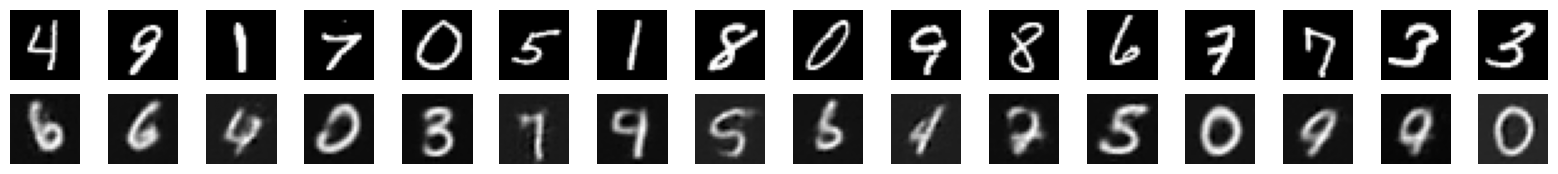

Generated 16 new images and training completed!


In [11]:
# Visualizing generated samples
vae.eval()
with torch.no_grad():
    z = torch.randn(16, 256).to(device) # Move latent vector to device
    generated = vae.decode(z)

    # Correctly unpack the images and labels from train_loader
    original_images_batch, _ = next(iter(train_loader))

    # Plot generated images and original images
    fig, axs = plt.subplots(2, 16, figsize=(20, 2))
    for i in range(16):
        # Plot original image from the batch
        axs[0,i].imshow(original_images_batch[i].squeeze().cpu().numpy(), cmap='gray')
        axs[0,i].axis('off')
        # Plot generated image
        axs[1,i].imshow(generated[i].squeeze().cpu().numpy(), cmap='gray')
        axs[1,i].axis('off')
    plt.show()

print("Generated 16 new images and training completed!")